# Loading and Preparing data

In [1]:
# Import pandas for data handling
import pandas as pd

# Load dataset
df = pd.read_csv("emotion_dataset.csv")

# Display first few rows to confirm loading
df.head()

,Sentence,Label
0,Unfortunately later died from eating tainted m...,happiness
1,Last time I saw was loooong ago. Basically bef...,neutral
2,You mean by number of military personnel? Beca...,neutral
3,Need to go middle of the road no NAME is going...,sadness
4,feel melty miserable enough imagine must,sadness


# Checking columns

In [2]:
# Import pandas for data handling
import pandas as pd

# Load dataset
df = pd.read_csv("emotion_dataset.csv")

# Display first few rows to confirm loading
df.head()

,Sentence,Label
0,Unfortunately later died from eating tainted m...,happiness
1,Last time I saw was loooong ago. Basically bef...,neutral
2,You mean by number of military personnel? Beca...,neutral
3,Need to go middle of the road no NAME is going...,sadness
4,feel melty miserable enough imagine must,sadness


# Renaming columns

In [3]:
# Rename columns for easier handling
# This ensures consistency throughout the analysis
df = df.rename(columns={
    "Sentence": "text",
    "Label": "label"
})

# Check column names
df.columns

Index(['text', 'label'], dtype='object')

# Text Processing

In [4]:
# Convert text to lowercase to ensure uniformity
df['clean_text'] = df['text'].str.lower()

# Display sample cleaned text
df[['text', 'clean_text']].head()

,text,clean_text
0,Unfortunately later died from eating tainted m...,unfortunately later died from eating tainted m...
1,Last time I saw was loooong ago. Basically bef...,last time i saw was loooong ago. basically bef...
2,You mean by number of military personnel? Beca...,you mean by number of military personnel? beca...
3,Need to go middle of the road no NAME is going...,need to go middle of the road no name is going...
4,feel melty miserable enough imagine must,feel melty miserable enough imagine must


# Encoding Labels

In [ ]:
# Import LabelEncoder to convert categorical labels into numeric form
from sklearn.preprocessing import LabelEncoder

# Initialize encoder
le = LabelEncoder()

# Transform labels into numeric values
df['label_encoded'] = le.fit_transform(df['label'])

# Check encoding result
df[['label', 'label_encoded']].head()

# Converting text into embeddings

In [6]:
# Import SentenceTransformer for advanced text embeddings
from sentence_transformers import SentenceTransformer

# Load pre-trained model (captures semantic meaning of text)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convert text into numerical vectors (feature matrix X)
# This is required because ML models cannot process raw text
X = model.encode(df['clean_text'], show_progress_bar=True)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4104 [00:00<?, ?it/s]

# Train-test split

In [7]:
# Import function to split dataset
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, df['label_encoded'], test_size=0.2, random_state=42
)

# Model 1 : Logistic Regression

In [13]:
# Import Logistic Regression model
from sklearn.linear_model import LogisticRegression

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Define parameter grid (testing different values of C)
param_grid = {
    'C': [0.1, 1, 10]
}

# Initialize base Logistic Regression model
lr = LogisticRegression(max_iter=1000)

# Set up Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=1
)

# Train models with different C values
grid_search.fit(X_train, y_train)

# Print best parameter
print("Best parameter:", grid_search.best_params_)

# Use best model
model_lr = grid_search.best_estimator_

# Train final model
model_lr.fit(X_train, y_train)

# Generate predictions
y_pred_lr = model_lr.predict(X_test)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best parameter: {'C': 10}


# Model 2 : Neural Network

In [9]:
# Import Neural Network model
from sklearn.neural_network import MLPClassifier

# Initialize model
model_nn = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300)

# Train model
model_nn.fit(X_train, y_train)

# Generate predictions
y_pred_nn = model_nn.predict(X_test)

C:\Users\LAV\Downloads\Programs\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


# Evaluation Metrics

In [10]:
# Import evaluation metrics
from sklearn.metrics import classification_report, accuracy_score

# Logistic Regression results
print("Logistic Regression Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# Neural Network results
print("Neural Network Results:")
print("Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

Logistic Regression Results:
Accuracy: 0.5056355190008377
              precision    recall  f1-score   support

           0       0.45      0.43      0.44      2668
           1       0.35      0.18      0.24      1615
           2       0.84      0.71      0.77       486
           3       0.42      0.35      0.38      1688
           4       0.58      0.51      0.54      1742
           5       0.51      0.39      0.44       685
           6       0.53      0.69      0.60      6349
           7       0.51      0.30      0.38      2078
           8       0.43      0.57      0.49      3171
           9       0.53      0.59      0.56      3527
          10       0.94      0.97      0.95       503
          11       0.51      0.28      0.36       839
          12       0.44      0.11      0.18       911

    accuracy                           0.51     26262
   macro avg       0.54      0.47      0.49     26262
weighted avg       0.50      0.51      0.49     26262

Neural Network Result

# Cross Validation

In [11]:
# Import cross-validation tools
from sklearn.model_selection import cross_val_score

# Perform 5-fold cross-validation on Logistic Regression
cv_scores = cross_val_score(model_lr, X, df['label_encoded'], cv=5, scoring='f1_macro')

# Print results
print("Cross-validation F1 scores:", cv_scores)
print("Mean F1 score:", cv_scores.mean())

Cross-validation F1 scores: [0.48216793 0.48570025 0.48345278 0.48570389 0.48944141]
Mean F1 score: 0.48529325222149833


# Confusion Matrices

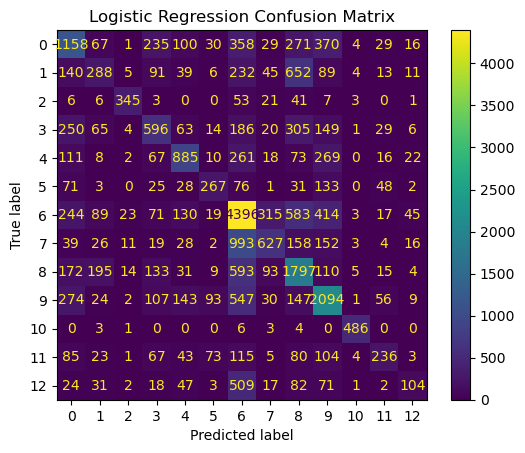

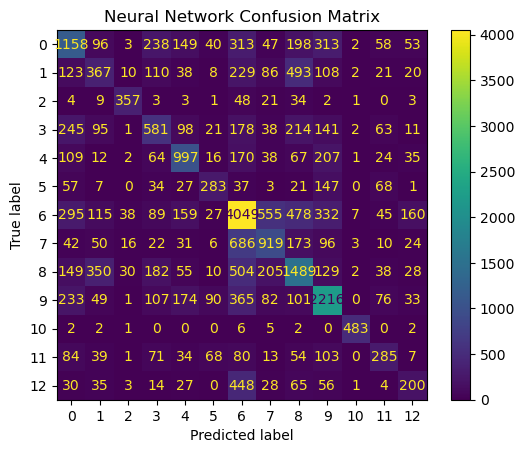

In [12]:
# Import confusion matrix tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Neural Network confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(cm_nn)
disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

# Logistic Regression Confusion Matrix

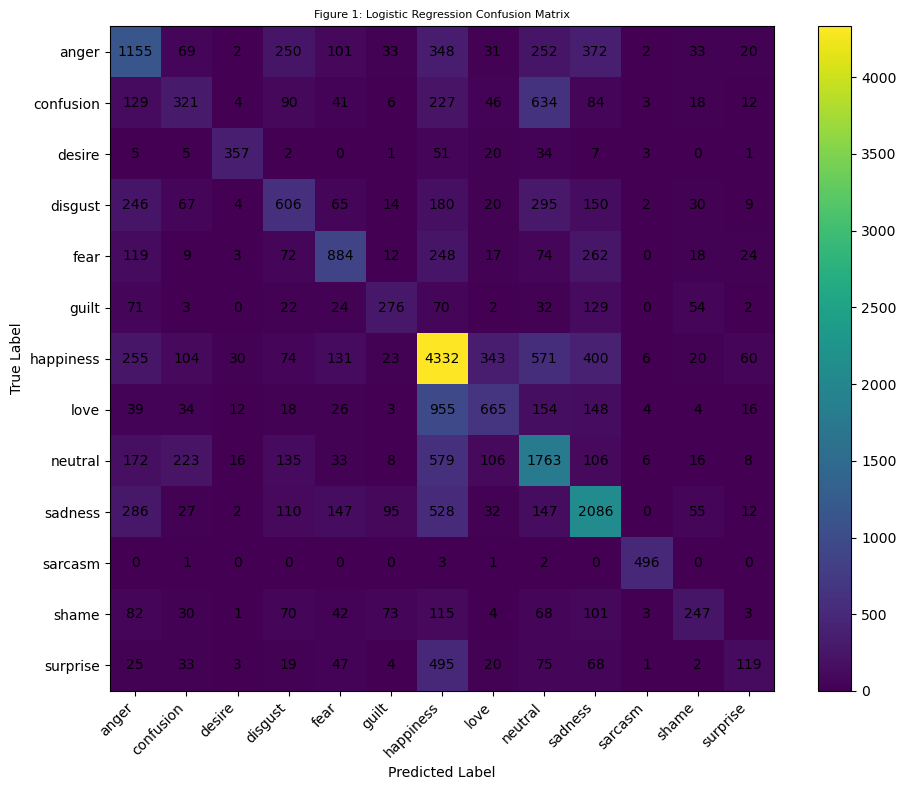

In [20]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Get class labels
labels = le.classes_

# Create large figure
plt.figure(figsize=(10, 8))

# Plot matrix
plt.imshow(cm_lr)

# Add title
plt.title("Figure 1: Logistic Regression Confusion Matrix", fontsize=8)

# Add colorbar
plt.colorbar()

# Add ticks
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add values inside cells
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_lr[i, j],
                 ha='center', va='center')

# Axis labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Improve layout
plt.tight_layout()

# Save figure
plt.savefig("figure1_logistic_regression_clean.png", dpi=300)

plt.show()

# Neural Network Confusion Matrix

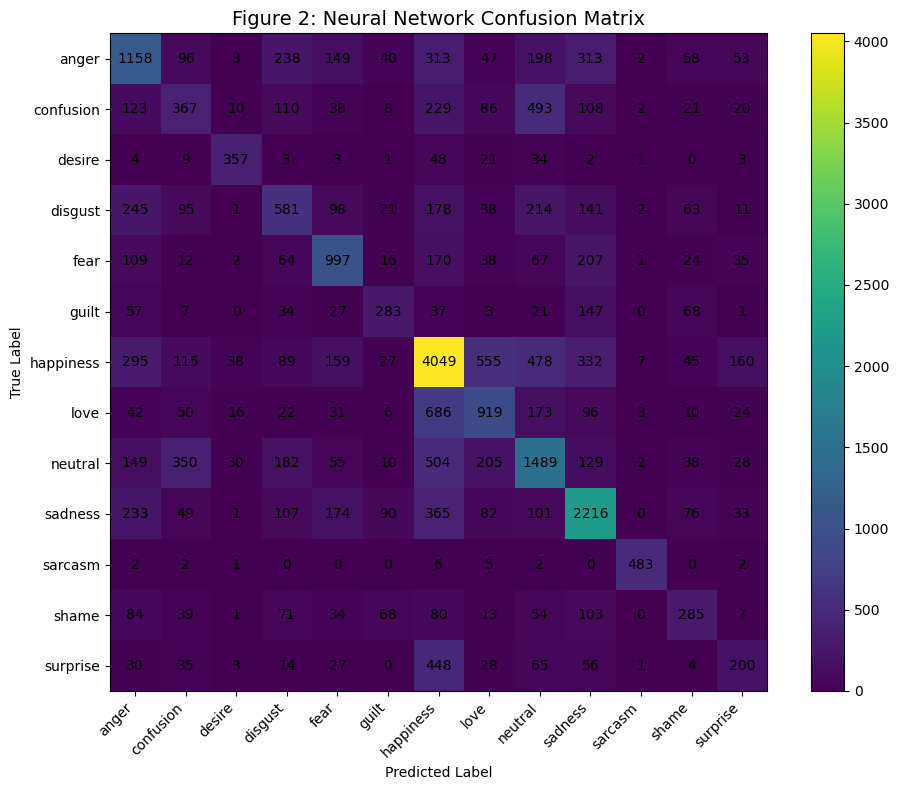

In [16]:
# Create confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)

# Create large figure
plt.figure(figsize=(10, 8))

# Plot matrix
plt.imshow(cm_nn)

# Title
plt.title("Figure 2: Neural Network Confusion Matrix", fontsize=14)

# Colorbar
plt.colorbar()

# Axis ticks
plt.xticks(ticks=np.arange(len(labels)), labels=labels, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add values
for i in range(len(labels)):
    for j in range(len(labels)):
        plt.text(j, i, cm_nn[i, j],
                 ha='center', va='center')

# Labels
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

# Layout
plt.tight_layout()

# Save
plt.savefig("figure2_neural_network_clean.png", dpi=300)

plt.show()

# Comparison Chart

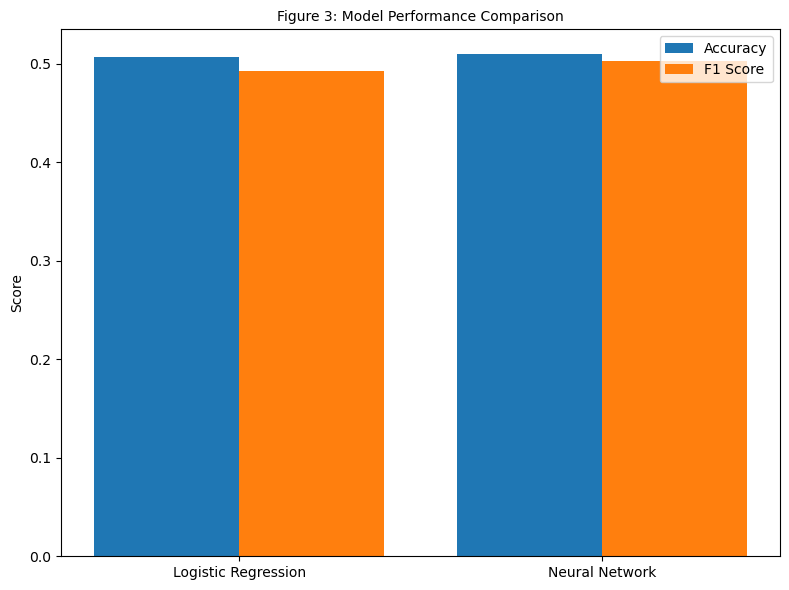

In [18]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
nn_accuracy = accuracy_score(y_test, y_pred_nn)

lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
nn_f1 = f1_score(y_test, y_pred_nn, average='macro')

# Data
models = ['Logistic Regression', 'Neural Network']
accuracy = [lr_accuracy, nn_accuracy]
f1_scores = [lr_f1, nn_f1]

x = np.arange(len(models))

# Bigger figure
plt.figure(figsize=(8, 6))

# Bars
plt.bar(x - 0.2, accuracy, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Score')

# Labels
plt.xticks(x, models)
plt.title("Figure 3: Model Performance Comparison", fontsize=10)
plt.ylabel("Score")

# Legend
plt.legend()

# Layout
plt.tight_layout()

# Save
plt.savefig("figure3_comparison_clean.png", dpi=300)

plt.show()